# Multiclass Classification: One-vs-All

> 📖 Book: [ch06](../../.claude/skills/ml-knowledge/chapters/ch06-logistic-regression.md) · Prev: [03](03_decision_boundary.ipynb) · Next: [03_classification_metrics](../03_classification_metrics/01_confusion_matrix_precision_recall_f1.ipynb)

Now there are more than two categories: $y \in \{0, 1, \dots, K-1\}$ (e.g. email folders *work / friends / family / hobby*, or the digits $0$–$9$).

**One-vs-all** (one-vs-rest) splits the problem into $K$ binary problems. For each class $k$ we relabel the data as "class $k$" ($1$) versus "everything else" ($0$) and train a logistic regression

$$
h_\theta^{(k)}(x) = p(y = k \mid x; \theta^{(k)}), \qquad k = 0, 1, \dots, K-1 .
$$

To classify a new $x$, run all $K$ classifiers and pick the most confident:

$$
\hat y = \arg\max_k h_\theta^{(k)}(x) .
$$

Stacking the $\theta^{(k)}$ as columns of $\Theta \in \mathbb{R}^{(n+1)\times K}$, all $K$ probabilities for all samples are $S(X\Theta)$ in one matrix product. In code: `ml.logistic.one_vs_all_fit` / `one_vs_all_predict`.

Note that the $K$ probabilities don't sum to 1: each classifier was trained independently. (Softmax regression fixes this by normalizing, $p_k = e^{z_k}/\sum_j e^{z_j}$.)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier

from ml.features.scaling import standardize
from ml.linear_models import add_bias
from ml.logistic import one_vs_all_fit, one_vs_all_predict, sigmoid
from ml.metrics import accuracy
from ml.visualization.plots import plot_decision_boundary

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(0)

centers = np.array([[0, 0], [4, 0], [2, 3.5]])
y = np.repeat([0, 1, 2], 50)
Xr = centers[y] + rng.normal(scale=0.9, size=(150, 2))
Z, transform = standardize(Xr)
X = add_bias(Z)
Theta = one_vs_all_fit(X, y, alpha=1.0)
print("Theta (one column per class):\n", Theta.round(2))

Theta (one column per class):
 [[-2.56 -3.13 -4.38]
 [-5.3   6.97  1.05]
 [-3.35 -4.15 14.74]]


### The three binary problems and the combined classifier

Each panel shows $h_\theta^{(k)}(x)$ for one classifier ("class $k$" vs. rest). The last panel takes the $\arg\max$.

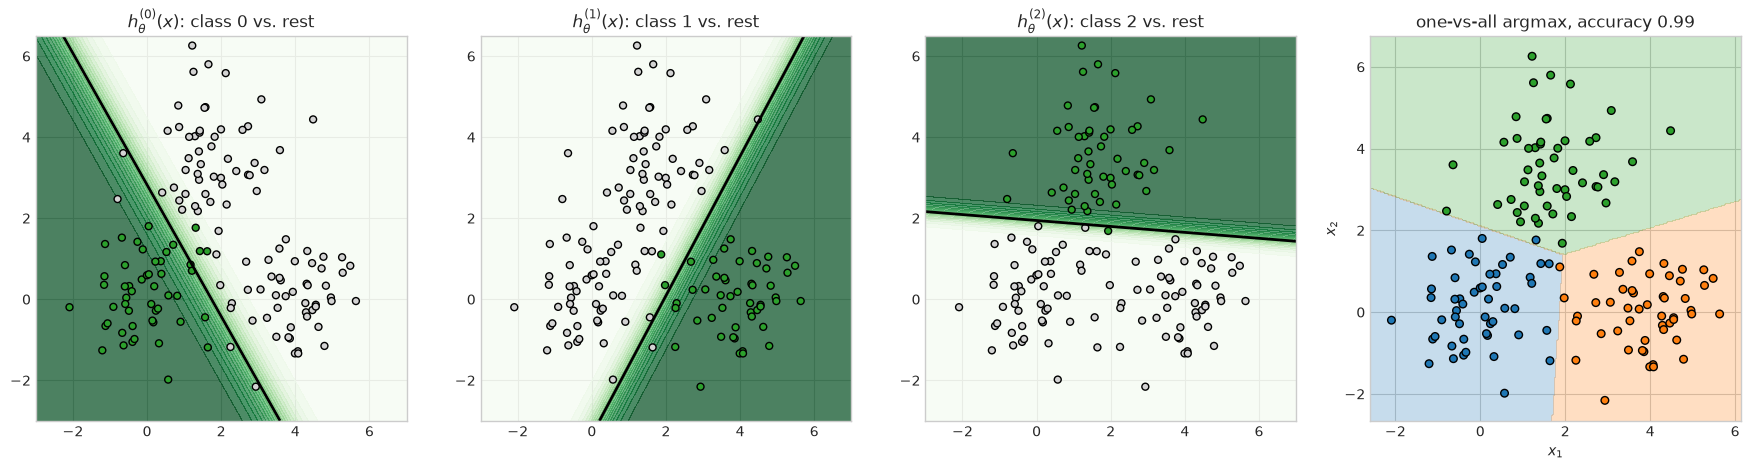

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
G1, G2 = np.meshgrid(np.linspace(-3, 7, 200), np.linspace(-3, 6.5, 200))
P = add_bias(transform(np.c_[G1.ravel(), G2.ravel()]))
for k, ax in enumerate(axes[:3]):
    hk = sigmoid(P @ Theta[:, k]).reshape(G1.shape)
    ax.contourf(G1, G2, hk, levels=20, cmap="Greens", alpha=0.7)
    ax.contour(G1, G2, hk, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(Xr[:, 0], Xr[:, 1], c=np.where(y == k, "C2", "lightgray"), edgecolors="k", s=25)
    ax.set_title(rf"$h^{{({k})}}_\theta(x)$: class {k} vs. rest")
plot_decision_boundary(lambda Q: one_vs_all_predict(Theta, add_bias(transform(Q))), Xr, y, ax=axes[3])
axes[3].set_title(f"one-vs-all argmax, accuracy {accuracy(y, one_vs_all_predict(Theta, X)):.2f}")
plt.show()

## A real example: handwritten digits

The scikit-learn digits dataset has 1797 images of $8 \times 8$ pixels, i.e. $n = 64$ features and $K = 10$ classes. We train 10 logistic regressions, compare with scikit-learn's `OneVsRestClassifier`, and look at what each classifier learned: its 64 weights reshaped as an image.

ml.logistic one-vs-all test accuracy: 0.965
sklearn OneVsRest test accuracy     : 0.969


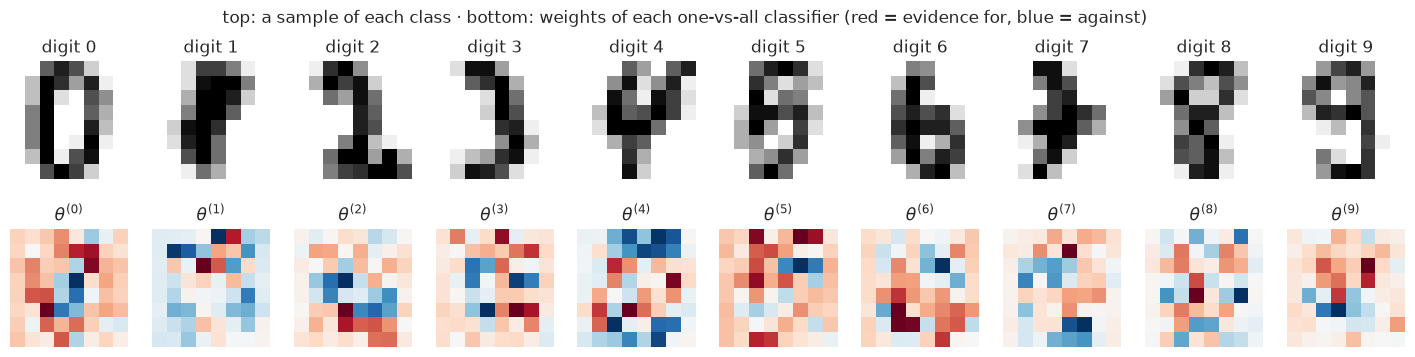

In [3]:
digits = load_digits()
Xtr, Xte, ytr, yte = train_test_split(digits.data, digits.target, test_size=0.3, random_state=0, stratify=digits.target)
Ztr, transform = standardize(Xtr)
Theta_d = one_vs_all_fit(add_bias(Ztr), ytr, alpha=0.5, lam=1.0, max_iter=2000)
pred = one_vs_all_predict(Theta_d, add_bias(transform(Xte)))
sk = OneVsRestClassifier(LogisticRegression(max_iter=2000)).fit(Ztr, ytr)
print(f"ml.logistic one-vs-all test accuracy: {accuracy(yte, pred):.3f}")
print(f"sklearn OneVsRest test accuracy     : {sk.score(transform(Xte), yte):.3f}")

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for k in range(10):
    axes[0, k].imshow(Xtr[ytr == k][0].reshape(8, 8), cmap="gray_r")
    axes[0, k].set_title(f"digit {k}")
    axes[1, k].imshow(Theta_d[1:, k].reshape(8, 8), cmap="RdBu_r")
    axes[1, k].set_title(rf"$\theta^{{({k})}}$")
for a in axes.ravel():
    a.axis("off")
fig.suptitle("top: a sample of each class · bottom: weights of each one-vs-all classifier (red = evidence for, blue = against)")
plt.show()

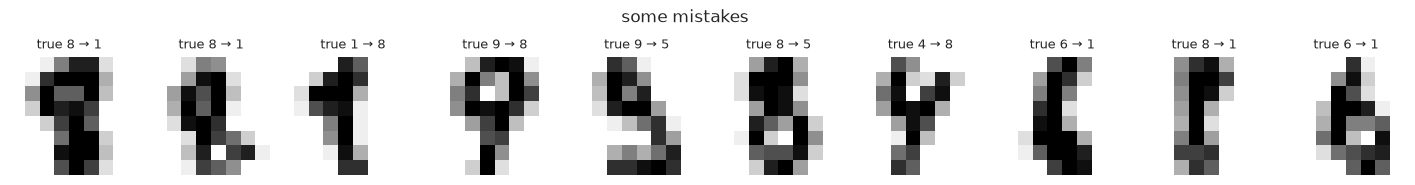

In [4]:
wrong = np.flatnonzero(pred != yte)[:10]
fig, axes = plt.subplots(1, len(wrong), figsize=(1.8 * len(wrong), 2.2))
for a, i in zip(np.atleast_1d(axes), wrong, strict=True):
    a.imshow(Xte[i].reshape(8, 8), cmap="gray_r")
    a.set_title(f"true {yte[i]} → {pred[i]}", fontsize=9)
    a.axis("off")
fig.suptitle("some mistakes")
plt.show()

## Summary

- $K$ classes → $K$ binary logistic regressions, prediction by $\arg\max_k h^{(k)}_\theta(x)$.
- Everything (cost, gradient, regularization, features) carries over from the binary case.
- To judge a multiclass model, look beyond accuracy: per-class precision/recall and the confusion matrix → next section.